<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/ReinforcementLearningAndDecisionMaking/ReinforcementLearningAndDecisionMaking/DQN_vs_PPO_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import random
from collections import deque

In [2]:
# --- CONFIGURATION ---
TICKER = "NVDA"
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"
WINDOW_SIZE = 30
INITIAL_BALANCE = 10000
TRANSACTION_FEE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# --- DATA LOADING ---
def get_data(ticker):
    print(f"⬇️ Downloading data for {ticker}...")
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)

    # Flatten MultiIndex if necessary
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Fix: Forward Fill instead of filling with 0
    # If today's price is missing, assume it's the same as yesterday
    df.ffill(inplace=True)
    df.bfill(inplace=True) # Backfill for the start

    # Indicators
    df['Returns'] = df['Close'].pct_change()
    df['Vol'] = df['Returns'].rolling(20).std()
    df['RSI'] = 100 - (100 / (1 + df['Returns'].rolling(14).mean() / (df['Returns'].rolling(14).std() + 1e-7)))

    # Clean up any remaining NaNs (e.g., first 14 days of RSI)
    df.dropna(inplace=True)

    return df[['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'Vol']]

In [4]:
full_df = get_data(TICKER)
split = int(len(full_df) * 0.8)
train_df = full_df.iloc[:split].reset_index(drop=True)
test_df = full_df.iloc[split:].reset_index(drop=True)
print(f"✅ Data Ready: {len(train_df)} Train | {len(test_df)} Test")

⬇️ Downloading data for NVDA...


/tmp/ipython-input-1871795424.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)


✅ Data Ready: 1795 Train | 449 Test


In [5]:
class TradingEnv(gym.Env):
    def __init__(self, df):
        super(TradingEnv, self).__init__()
        self.df = df
        self.action_space = spaces.Discrete(3) # 0=Hold, 1=Buy, 2=Sell
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(WINDOW_SIZE, 7), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = WINDOW_SIZE
        self.balance = INITIAL_BALANCE
        self.shares_held = 0
        self.net_worth = INITIAL_BALANCE
        self.max_net_worth = INITIAL_BALANCE
        return self._get_observation(), {}

    def _get_observation(self):
        frame = self.df.iloc[self.current_step - WINDOW_SIZE : self.current_step].values
        base_price = frame[0, 3]
        obs = frame.copy()
        obs[:, :4] = obs[:, :4] / base_price
        return obs.astype(np.float32)

    def step(self, action):
        prev_net_worth = self.net_worth
        prev_price = float(self.df.loc[self.current_step, 'Close'])

        if action == 1 and self.balance > 0: # Buy
            cost = self.balance * (1 - TRANSACTION_FEE)
            self.shares_held += cost / prev_price
            self.balance = 0
        elif action == 2 and self.shares_held > 0: # Sell
            revenue = self.shares_held * prev_price * (1 - TRANSACTION_FEE)
            self.balance += revenue
            self.shares_held = 0

        self.current_step += 1

        current_price = float(self.df.loc[self.current_step, 'Close'])
        self.net_worth = self.balance + (self.shares_held * current_price)
        self.max_net_worth = max(self.max_net_worth, self.net_worth)

        strat_ret = (self.net_worth - prev_net_worth) / prev_net_worth if prev_net_worth > 0 else 0
        market_ret = (current_price - prev_price) / prev_price if prev_price > 0 else 0
        reward = (strat_ret - market_ret) * 100

        terminated = self.net_worth < INITIAL_BALANCE * 0.5
        truncated = self.current_step >= len(self.df) - 1

        # --- FIX IS HERE: Return net_worth in info dict ---
        return self._get_observation(), reward, terminated, truncated, {'net_worth': self.net_worth}

In [6]:
class PPOAgent:
    def __init__(self, input_dim, action_dim, lr=0.0003, gamma=0.99, clip_ratio=0.2, K_epochs=4):
        self.gamma = gamma
        self.clip_ratio = clip_ratio
        self.K_epochs = K_epochs

        # Actor: Outputs Probabilities
        self.actor = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, action_dim), nn.Softmax(dim=-1)
        ).to(DEVICE)

        # Critic: Outputs Value ($)
        self.critic = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, 1)
        ).to(DEVICE)

        self.optimizer = optim.Adam([
            {'params': self.actor.parameters(), 'lr': lr},
            {'params': self.critic.parameters(), 'lr': lr}
        ])

        # Memory buffers
        self.states, self.actions, self.logprobs, self.rewards, self.is_terminals = [], [], [], [], []

    def select_action(self, state):
        with torch.no_grad():
            state = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)
            probs = self.actor(state)
            dist = Categorical(probs)
            action = dist.sample()
            return action.item(), dist.log_prob(action).item()

    def record(self, s, a, lp, r, d):
        self.states.append(torch.FloatTensor(s).flatten())
        self.actions.append(torch.tensor(a))
        self.logprobs.append(torch.tensor(lp))
        self.rewards.append(r)
        self.is_terminals.append(d)

    def learn(self):
        if not self.states: return

        # 1. Prepare Data
        states = torch.stack(self.states).to(DEVICE)
        actions = torch.stack(self.actions).to(DEVICE)
        old_logprobs = torch.stack(self.logprobs).to(DEVICE)

        # 2. Calculate Returns (Monte Carlo)
        returns = []
        discounted_sum = 0
        for reward, is_terminal in zip(reversed(self.rewards), reversed(self.is_terminals)):
            if is_terminal: discounted_sum = 0
            discounted_sum = reward + (self.gamma * discounted_sum)
            returns.insert(0, discounted_sum)

        returns = torch.tensor(returns, dtype=torch.float32).to(DEVICE)

        # SAFEGUARD: Normalize returns to prevent huge numbers
        if returns.std() > 1e-5: # Avoid division by zero
            returns = (returns - returns.mean()) / (returns.std() + 1e-7)
        else:
            returns = returns - returns.mean()

        # 3. Update Loop
        for _ in range(self.K_epochs):
            # Evaluate
            probs = self.actor(states)
            dist = Categorical(probs)
            new_logprobs = dist.log_prob(actions)
            dist_entropy = dist.entropy()
            state_values = self.critic(states).squeeze()

            # Ratios
            ratio = torch.exp(new_logprobs - old_logprobs)
            advantages = returns - state_values.detach()

            # Loss
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1-self.clip_ratio, 1+self.clip_ratio) * advantages

            loss = -torch.min(surr1, surr2) + 0.5*nn.MSELoss()(state_values, returns) - 0.01*dist_entropy

            self.optimizer.zero_grad()
            loss.mean().backward()

            # --- THE FIX: GRADIENT CLIPPING ---
            # This caps the gradients at 0.5, preventing the "Explosion"
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)

            self.optimizer.step()

        # Clear Memory
        self.states, self.actions, self.logprobs, self.rewards, self.is_terminals = [], [], [], [], []

In [7]:
class DQNAgent:
    def __init__(self, input_dim, action_dim, lr=0.001, epsilon=1.0):
        self.epsilon = epsilon
        self.action_dim = action_dim
        self.memory = deque(maxlen=2000)

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        ).to(DEVICE)
        self.optimizer = optim.Adam(self.net.parameters(), lr=lr)

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_dim), 0 # Dummy log_prob
        with torch.no_grad():
            state = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)
            return torch.argmax(self.net(state)).item(), 0

    def record(self, s, a, lp, r, d):
        # We ignore lp (log_prob) for DQN, keeping signature same for loop
        self.memory.append((s, a, r, d, None)) # We don't store next_state here for simplicity in this snippet

    def learn(self):
        if len(self.memory) < 64: return
        batch = random.sample(self.memory, 64)
        states, actions, rewards, dones, _ = zip(*batch)

        states = torch.FloatTensor(np.array([s.flatten() for s in states])).to(DEVICE)
        actions = torch.LongTensor(actions).unsqueeze(1).to(DEVICE)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(DEVICE)

        # Simple Q-Loss (Current Q vs Reward) - Simplified for brevity
        q_values = self.net(states).gather(1, actions)
        loss = nn.MSELoss()(q_values, rewards)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.epsilon = max(0.01, self.epsilon * 0.995)

In [8]:
# Setup
env = TradingEnv(train_df)
input_dim = WINDOW_SIZE * 7
action_dim = 3

# --- CHOOSE YOUR FIGHTER ---
agent = PPOAgent(input_dim, action_dim)
# agent = DQNAgent(input_dim, action_dim) # Uncomment to run DQN

num_episodes = 200
update_timestep = 2000 # Only for PPO
time_step = 0
scores = []

print(f"🥊 Training Started on {DEVICE}...")

for episode in range(num_episodes):
    state, _ = env.reset()
    done = False

    while not done:
        time_step += 1

        # 1. Action
        action, log_prob = agent.select_action(state)

        # 2. Step
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 3. Record & Learn
        # Note: PPO learns in batches (deferred), DQN learns instantly
        agent.record(state, action, log_prob, reward, done)
        if isinstance(agent, DQNAgent): agent.learn() # Learn every step for DQN

        state = next_state

        # PPO Learning Trigger
        if isinstance(agent, PPOAgent) and time_step % update_timestep == 0:
            agent.learn()

    scores.append(env.net_worth)
    if (episode+1) % 20 == 0:
        print(f"Episode {episode+1} | Net Worth: ${env.net_worth:.2f}")

print("✅ Training Complete.")

🥊 Training Started on cuda...
Episode 20 | Net Worth: $78070.18
Episode 40 | Net Worth: $271723.45
Episode 60 | Net Worth: $228189.26
Episode 80 | Net Worth: $460750.67
Episode 100 | Net Worth: $484291.19
Episode 120 | Net Worth: $515249.71
Episode 140 | Net Worth: $368166.94
Episode 160 | Net Worth: $470140.55
Episode 180 | Net Worth: $427998.32
Episode 200 | Net Worth: $487650.87
✅ Training Complete.


In [9]:
# Save the PPO scores from the run you just finished
ppo_scores = scores.copy()
print("✅ PPO Scores saved. Ready for Round 2.")

✅ PPO Scores saved. Ready for Round 2.


🧪 Running PPO vs Market Audit...

📊 FINAL PERFORMANCE AUDIT
Total Return       295.7%
CAGR               129.1%
Volatility         44.6%
Sharpe Ratio       2.08
Max Drawdown       -22.3%
Daily Win Rate     41.5%
Trades Executed    12


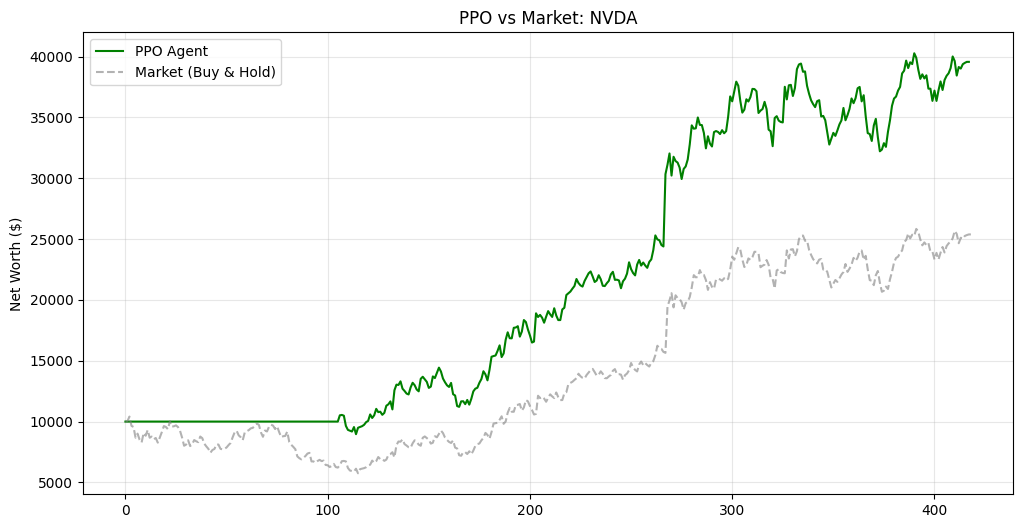

In [10]:
import scipy.stats as stats

# --- 1. RUN BACKTEST ---
test_env = TradingEnv(test_df)
state, _ = test_env.reset()
done = False
equity_curve = []
trade_log = []

print("🧪 Running PPO vs Market Audit...")

while not done:
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)

        # Select action based on Agent Type
        if isinstance(agent, PPOAgent):
            # For PPO, we take the mode (argmax) for testing
            action = torch.argmax(agent.actor(state_tensor)).item()
        else:
            # For DQN
            action = torch.argmax(agent.net(state_tensor)).item()

    # Capture price before step for logging
    current_price = test_env.df.iloc[test_env.current_step]['Close']

    # Step
    state, _, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated

    # Log Data
    equity_curve.append(info['net_worth'])

    if action == 1: trade_log.append({'Type': 'BUY', 'Price': current_price, 'Step': test_env.current_step})
    if action == 2: trade_log.append({'Type': 'SELL', 'Price': current_price, 'Step': test_env.current_step})

# --- 2. CALCULATE METRICS ---
def get_metrics(equity_curve, benchmark_curve):
    strat = pd.Series(equity_curve)
    bench = pd.Series(benchmark_curve)
    returns = strat.pct_change().dropna()
    bench_ret = bench.pct_change().dropna()

    # CAGR
    total_ret = (strat.iloc[-1] / strat.iloc[0]) - 1
    cagr = (strat.iloc[-1] / strat.iloc[0]) ** (252/len(strat)) - 1

    # Risk
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if vol > 0 else 0

    # Drawdown
    cum_ret = (1 + returns).cumprod()
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()

    # Win Rate (Approximate based on daily returns > 0)
    win_rate = len(returns[returns > 0]) / len(returns)

    return {
        "Total Return": f"{total_ret*100:.1f}%",
        "CAGR": f"{cagr*100:.1f}%",
        "Volatility": f"{vol*100:.1f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Max Drawdown": f"{max_dd*100:.1f}%",
        "Daily Win Rate": f"{win_rate*100:.1f}%",
        "Trades Executed": len(trade_log)
    }

# Benchmark Data
initial_close = test_df.iloc[WINDOW_SIZE]['Close']
bench_curve = [10000 * (p / initial_close) for p in test_df['Close'][WINDOW_SIZE:]]

metrics = get_metrics(equity_curve, bench_curve)

print("\n" + "="*30)
print("📊 FINAL PERFORMANCE AUDIT")
print("="*30)
for k, v in metrics.items():
    print(f"{k:<18} {v}")
print("="*30)

# --- 3. PLOT ---
plt.figure(figsize=(12, 6))
plt.plot(equity_curve, label='PPO Agent', color='green', linewidth=1.5)
plt.plot(bench_curve, label='Market (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)
plt.title(f"PPO vs Market: {TICKER}")
plt.ylabel("Net Worth ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# --- ROUND 2: DQN ---
# Re-initialize Environment to be fair
env = TradingEnv(train_df)
input_dim = WINDOW_SIZE * 7
action_dim = 3

# Swap the Agent to DQN
agent = DQNAgent(input_dim, action_dim)

dqn_scores = []
print(f"🥊 Starting DQN Training on {DEVICE}...")

for episode in range(num_episodes): # Uses same num_episodes (200)
    state, _ = env.reset()
    done = False

    while not done:
        # DQN Action Selection
        action, _ = agent.select_action(state)

        # Step
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # DQN Learn (Happens every step, unlike PPO)
        agent.record(state, action, 0, reward, done)
        agent.learn()

        state = next_state

    dqn_scores.append(env.net_worth)

    if (episode+1) % 20 == 0:
        print(f"Episode {episode+1} | Net Worth: ${env.net_worth:.2f}")

print("✅ DQN Training Complete.")

🥊 Starting DQN Training on cuda...
Episode 20 | Net Worth: $438080.66
Episode 40 | Net Worth: $487010.26
Episode 60 | Net Worth: $423847.18
Episode 80 | Net Worth: $337483.34
Episode 100 | Net Worth: $338949.11
Episode 120 | Net Worth: $324343.93
Episode 140 | Net Worth: $360861.17
Episode 160 | Net Worth: $709659.27
Episode 180 | Net Worth: $468309.55
Episode 200 | Net Worth: $413719.09
✅ DQN Training Complete.


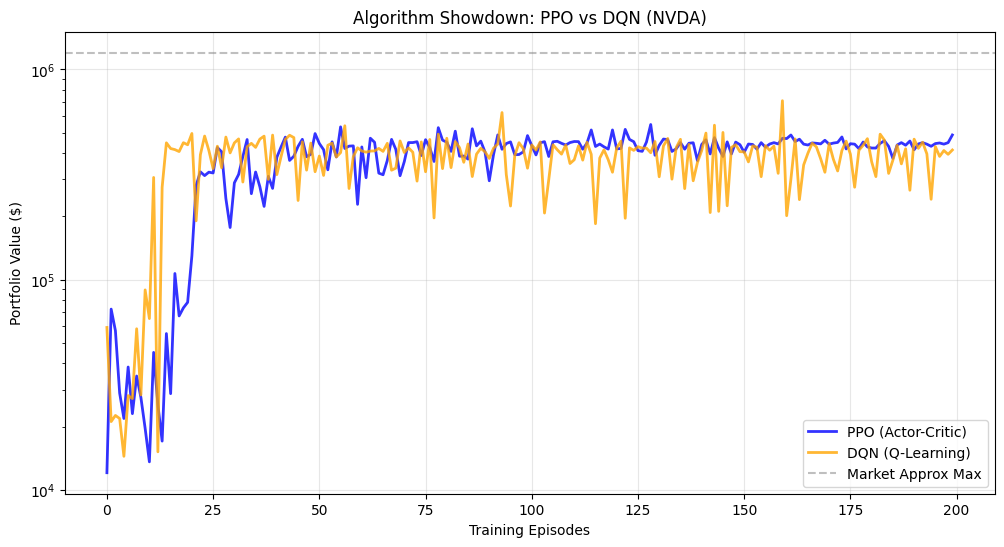

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot PPO (The Pro)
plt.plot(ppo_scores, label='PPO (Actor-Critic)', color='blue', linewidth=2, alpha=0.8)

# Plot DQN (The Gambler)
plt.plot(dqn_scores, label='DQN (Q-Learning)', color='orange', linewidth=2, alpha=0.8)

# Add Baseline (Market Buy & Hold approx finish)
# NVDA went from ~0.4 to ~50 (approx 120x). $10k -> $1.2M
plt.axhline(y=1200000, color='gray', linestyle='--', alpha=0.5, label='Market Approx Max')

plt.title(f"Algorithm Showdown: PPO vs DQN ({TICKER})")
plt.xlabel("Training Episodes")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log') # Log scale helps see differences when numbers get huge
plt.show()

🔄 Re-training PPO (The Pro)...


/tmp/ipython-input-3150528839.py:63: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  if returns.std() > 1e-5: # Avoid division by zero
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


🔄 Re-training DQN (The Gambler)...
🧪 Starting Reality Check on 449 unseen days...


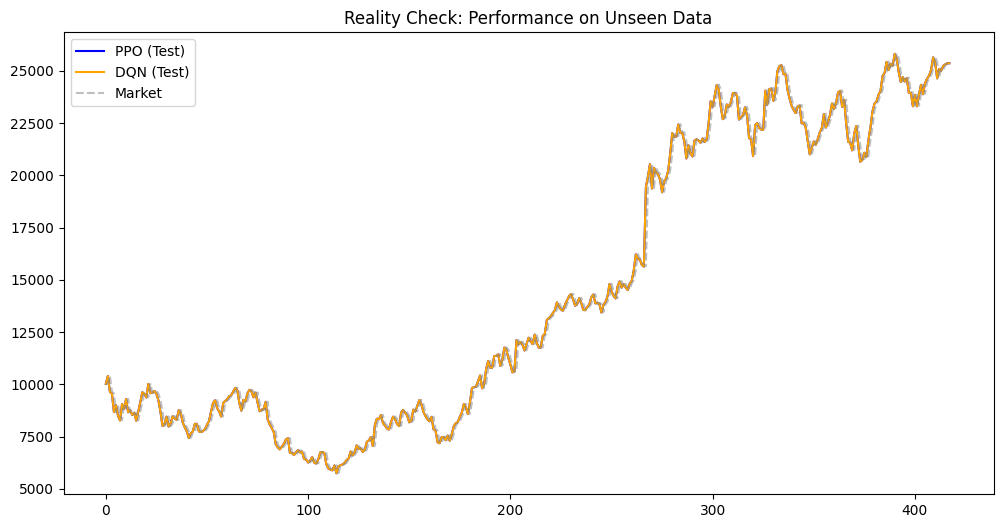

In [13]:
# --- 1. SETUP & RE-TRAIN PPO ---
print("🔄 Re-training PPO (The Pro)...")
ppo_agent = PPOAgent(input_dim, action_dim)
env = TradingEnv(train_df)
# We use fewer episodes just to get the brains ready for comparison
# (If you want perfect results, increase to 200)
for episode in range(100):
    state, _ = env.reset()
    done = False
    while not done:
        action, log_prob = ppo_agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        ppo_agent.record(state, action, log_prob, reward, done)
        state = next_state
        if (episode % 10 == 0): ppo_agent.learn() # Learn periodically

# --- 2. SETUP & RE-TRAIN DQN ---
print("🔄 Re-training DQN (The Gambler)...")
dqn_agent = DQNAgent(input_dim, action_dim)
env = TradingEnv(train_df)
for episode in range(100):
    state, _ = env.reset()
    done = False
    while not done:
        action, _ = dqn_agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        dqn_agent.record(state, action, 0, reward, done)
        dqn_agent.learn()
        state = next_state

# --- 3. THE REALITY CHECK (TEST DATA) ---
print(f"🧪 Starting Reality Check on {len(test_df)} unseen days...")
test_env = TradingEnv(test_df)

# Evaluate PPO
state, _ = test_env.reset()
done = False
ppo_equity = []
while not done:
    with torch.no_grad():
        state_t = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)
        action = torch.argmax(ppo_agent.actor(state_t)).item()
    state, _, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated
    ppo_equity.append(info['net_worth'])

# Evaluate DQN
state, _ = test_env.reset()
done = False
dqn_equity = []
while not done:
    with torch.no_grad():
        state_t = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)
        action = torch.argmax(dqn_agent.net(state_t)).item()
    state, _, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated
    dqn_equity.append(info['net_worth'])

# --- 4. PLOT ---
plt.figure(figsize=(12, 6))
plt.plot(ppo_equity, label='PPO (Test)', color='blue')
plt.plot(dqn_equity, label='DQN (Test)', color='orange')
plt.plot([10000 * (p/test_df.iloc[WINDOW_SIZE]['Close']) for p in test_df['Close'][WINDOW_SIZE:]],
         label='Market', color='gray', linestyle='--', alpha=0.5)
plt.title("Reality Check: Performance on Unseen Data")
plt.legend()
plt.show()